# EfficientNet Training — 3-Class MP Classification (Kaggle)

This notebook trains an EfficientNet classifier to classify microplastic crops into:
- fiber
- film
- fragment

It follows the same Kaggle-safe path logic used in your working YOLO notebook:
- Auto-detect dataset under /kaggle/input
- Copy dataset to /kaggle/working
- Robust checkpoint and backup handling

## Accuracy-Oriented Training Strategy

1. Stage A (head warmup): freeze backbone, train classifier head
2. Stage B (full fine-tune): unfreeze all layers with lower LR
3. Class-weighted loss + weighted sampling for class imbalance
4. Cosine LR schedule, mixed precision, early stopping

This is configured for research-quality accuracy rather than minimum runtime.

## 1. Install Dependencies

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'timm', 'scikit-learn', 'seaborn'], check=True)
print('Dependencies installed.')

Dependencies installed.


## 2. GPU Verification & Reproducibility

In [2]:
import os
import random
import numpy as np
import torch
import psutil

assert torch.cuda.is_available(), 'No GPU detected. In Kaggle set Accelerator to GPU.'

print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.version.cuda}')
print(f'RAM total: {psutil.virtual_memory().total / 1e9:.1f} GB')
print(f'Disk free: {psutil.disk_usage('/kaggle/working').free / 1e9:.1f} GB')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Seed: {SEED}')

GPU: Tesla T4
PyTorch: 2.9.0+cu126
CUDA: 12.6
RAM total: 33.7 GB
Disk free: 20.9 GB
Seed: 42


## 3. Auto-Detect Dataset and Copy to /kaggle/working

In [3]:
import shutil
from pathlib import Path

INPUT_ROOT = Path('/kaggle/input')
LOCAL_DATASET = Path('/kaggle/working/crops_dataset')
OUTPUT_ROOT = Path('/kaggle/working/experiments/efficientnet/mp_effnet_b3_cls3')
BACKUP_ROOT = Path('/kaggle/working/backups/efficientnet')

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
BACKUP_ROOT.mkdir(parents=True, exist_ok=True)

print('Top-level /kaggle/input entries:')
print(sorted([p.name for p in INPUT_ROOT.iterdir()]))

# Find candidate datasets that look like crop-classification data
candidates = []
for p in INPUT_ROOT.rglob('*'):
    if not p.is_dir():
        continue
    has_class_dirs = all((p / c).is_dir() for c in ['fiber', 'film', 'fragment'])
    has_annotations = (p / 'annotations.json').exists()
    has_images = (p / 'images').is_dir()
    if has_class_dirs or (has_annotations and has_images):
        score = 0
        s = str(p).lower()
        if 'crops_augmented' in s:
            score += 4
        if 'crops_gt_sam' in s:
            score += 3
        if 'sam' in s:
            score += 1
        candidates.append((score, p))

assert candidates, 'No valid crop dataset found in /kaggle/input. Need either class dirs or annotations+images.'
candidates = sorted(candidates, key=lambda x: x[0], reverse=True)
SRC_DATASET = candidates[0][1]
print(f'Using dataset source: {SRC_DATASET}')

if LOCAL_DATASET.exists():
    print(f'Dataset already copied: {LOCAL_DATASET}')
else:
    print(f'Copying dataset to {LOCAL_DATASET} ...')
    shutil.copytree(str(SRC_DATASET), str(LOCAL_DATASET))
    print('Copy complete.')

print('Dataset ready.')

Top-level /kaggle/input entries:
['datasets']
Using dataset source: /kaggle/input/datasets/mpdetect/crops-augmented
Copying dataset to /kaggle/working/crops_dataset ...
Copy complete.
Dataset ready.


## 4. Dataset Class and Data Transforms

In [4]:
import json
from PIL import Image
from collections import Counter

from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from torchvision import transforms

NUM_CLASSES = 3
CLASS_NAMES = ['fiber', 'film', 'fragment']
CLASS_NAME_TO_ID = {'fiber': 0, 'film': 1, 'fragment': 2}
IMG_SIZE = 300  # EfficientNet-B3 native

class CropClassificationDataset(Dataset):
    """Supports 3 layouts:
      1) annotations.json + images/
      2) root/{fiber,film,fragment}/*
      3) root/{train,val}/{fiber,film,fragment}/*
    """
    def __init__(self, crops_dir, transform=None, split=None):
        self.crops_dir = Path(crops_dir)
        self.transform = transform
        self.samples = []

        ann_file = self.crops_dir / 'annotations.json'
        split_dir = self.crops_dir / split if split else None
        has_split_dirs = split_dir is not None and split_dir.is_dir() and any((split_dir / cn).is_dir() for cn in CLASS_NAMES)

        if has_split_dirs:
            for cls_name, cls_id in CLASS_NAME_TO_ID.items():
                cls_dir = split_dir / cls_name
                if not cls_dir.is_dir():
                    continue
                for f in sorted(cls_dir.glob('*')):
                    if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
                        self.samples.append((str(f), cls_id))
        elif ann_file.exists():
            with open(ann_file) as f:
                annotations = json.load(f)
            for filename, ann in annotations.items():
                if split and ann.get('split', '') != split:
                    continue
                cls_id = ann['class_id']
                img_path = self.crops_dir / 'images' / filename
                if not img_path.exists():
                    cls_name = ann.get('class_name', CLASS_NAMES[cls_id])
                    img_path = self.crops_dir / cls_name / filename
                if img_path.exists():
                    self.samples.append((str(img_path), cls_id))
        else:
            for cls_name, cls_id in CLASS_NAME_TO_ID.items():
                cls_dir = self.crops_dir / cls_name
                if not cls_dir.is_dir():
                    continue
                for f in sorted(cls_dir.glob('*')):
                    if f.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'):
                        self.samples.append((str(f), cls_id))

        counts = [0, 0, 0]
        for _, cls_id in self.samples:
            counts[cls_id] += 1
        split_text = f' ({split})' if split else ''
        print(f'Loaded {len(self.samples)} samples{split_text} from {crops_dir}')
        for i, n in enumerate(CLASS_NAMES):
            print(f'  {n}: {counts[i]}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(25),
            transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.2, hue=0.04),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.12)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

print('Dataset and transforms ready.')

Dataset and transforms ready.


## 5. Data Split, Class Balance, and Loaders

In [5]:
# Hyperparameters tuned for high accuracy
EPOCHS_HEAD = 12
EPOCHS_FINE = 68
BATCH_SIZE = 16
LR_HEAD = 3e-4
LR_FINE = 8e-5
WEIGHT_DECAY = 1e-2
VAL_SPLIT = 0.2
EARLY_STOP_PATIENCE = 16
LABEL_SMOOTHING = 0.05
BACKUP_EVERY = 5

# Build datasets
crops_path = LOCAL_DATASET
ann_file = crops_path / 'annotations.json'
has_split_dirs = (crops_path / 'train').is_dir() and all((crops_path / 'train' / c).is_dir() for c in CLASS_NAMES)

has_ann_splits = False
if ann_file.exists():
    with open(ann_file) as f:
        anns = json.load(f)
    has_ann_splits = any('split' in v for v in anns.values())

if has_split_dirs or has_ann_splits:
    train_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=True), split='train')
    val_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=False), split='val')
else:
    full_dataset = CropClassificationDataset(str(crops_path), transform=get_transforms(train=True))
    val_size = int(len(full_dataset) * VAL_SPLIT)
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
    print(f'Random split -> train: {train_size}, val: {val_size}')

# Weighted sampling for class balance
if isinstance(train_dataset, torch.utils.data.Subset):
    base = train_dataset.dataset
    idxs = train_dataset.indices
    labels = [base.samples[i][1] for i in idxs]
else:
    labels = [x[1] for x in train_dataset.samples]

label_counts = Counter(labels)
sample_weights = [1.0 / label_counts[l] for l in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

# Class weights for loss
counts = np.array([label_counts.get(i, 1) for i in range(NUM_CLASSES)], dtype=np.float32)
class_weights = 1.0 / np.maximum(counts, 1)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print('Class weights:', class_weights.numpy())

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=use_cuda, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=use_cuda, persistent_workers=True)

print('Dataloaders ready.')

Loaded 7791 samples (train) from /kaggle/working/crops_dataset
  fiber: 2959
  film: 2154
  fragment: 2678
Loaded 2221 samples (val) from /kaggle/working/crops_dataset
  fiber: 953
  film: 384
  fragment: 884
Class weights: [0.862403  1.184703  0.9528941]
Dataloaders ready.


## 6. Model + Training Functions

In [6]:
import timm
import torch.nn as nn
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_model(freeze_backbone=False):
    model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=NUM_CLASSES)
    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'classifier' not in name:
                p.requires_grad = False
    return model

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    all_true, all_pred = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        preds = logits.argmax(1)
        total_loss += loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(len(loader), 1)
    acc = correct / max(total, 1)
    return avg_loss, acc, all_true, all_pred

def train_stage(model, train_loader, val_loader, epochs, lr, stage_name, start_epoch=0, best_acc=0.0):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 0.05)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)
    scaler = torch.amp.GradScaler(device=device.type, enabled=(device.type == 'cuda'))

    history = []
    no_improve = 0

    print('')
    print('=' * 80)
    print(f'STAGE: {stage_name}')
    print(f'Epochs: {epochs} | LR: {lr} | Trainable params: {sum(p.numel() for p in params):,}')
    print('=' * 80)

    for e in range(epochs):
        epoch_num = start_epoch + e + 1
        tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, scaler=scaler)
        va_loss, va_acc, y_true, y_pred = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)
        scheduler.step()

        history.append({'epoch': epoch_num, 'train_loss': tr_loss, 'train_acc': tr_acc, 'val_loss': va_loss, 'val_acc': va_acc})

        print(f'Epoch {epoch_num:03d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.2%} | val_loss={va_loss:.4f} val_acc={va_acc:.2%}')

        ckpt = {
            'epoch': epoch_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': va_acc,
            'history': history,
            'stage': stage_name,
        }
        torch.save(ckpt, OUTPUT_ROOT / 'efficientnet_latest.pth')

        if va_acc > best_acc:
            best_acc = va_acc
            no_improve = 0
            torch.save(ckpt, OUTPUT_ROOT / 'efficientnet_best.pth')
            print(f'  -> new best: {best_acc:.2%}')
        else:
            no_improve += 1

        if epoch_num % BACKUP_EVERY == 0:
            bdir = BACKUP_ROOT / f'epoch_{epoch_num:04d}'
            bdir.mkdir(parents=True, exist_ok=True)
            for fn in ['efficientnet_latest.pth', 'efficientnet_best.pth']:
                src = OUTPUT_ROOT / fn
                if src.exists():
                    shutil.copy2(str(src), str(bdir / fn))
            print(f'  [AUTO-BACKUP] {bdir}')

        if no_improve >= EARLY_STOP_PATIENCE:
            print(f'  [EARLY STOP] no improvement for {EARLY_STOP_PATIENCE} epochs')
            break

    return best_acc, history

print('Training functions ready.')

Training functions ready.


## 7. Train (Stage A + Stage B)

In [7]:
model = get_model(freeze_backbone=True).to(device)
best_acc = 0.0
all_history = []

# Stage A: classifier head warmup
best_acc, h1 = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_HEAD,
    lr=LR_HEAD,
    stage_name='head_warmup',
    start_epoch=0,
    best_acc=best_acc
)
all_history.extend(h1)

# Stage B: full fine-tuning
for p in model.parameters():
    p.requires_grad = True

best_acc, h2 = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS_FINE,
    lr=LR_FINE,
    stage_name='full_finetune',
    start_epoch=len(all_history),
    best_acc=best_acc
)
all_history.extend(h2)

print('')
print('=' * 80)
print('TRAINING COMPLETE')
print(f'Best val acc: {best_acc:.2%}')
print(f'Best checkpoint: {OUTPUT_ROOT / "efficientnet_best.pth"}')
print('=' * 80)

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


STAGE: head_warmup
Epochs: 12 | LR: 0.0003 | Trainable params: 4,611
Epoch 001 | train_loss=2.3293 train_acc=37.00% | val_loss=nan val_acc=45.07%
  -> new best: 45.07%
Epoch 002 | train_loss=1.5110 train_acc=54.60% | val_loss=1.3043 val_acc=59.39%
  -> new best: 59.39%
Epoch 003 | train_loss=1.2693 train_acc=60.98% | val_loss=1.1495 val_acc=64.48%
  -> new best: 64.48%
Epoch 004 | train_loss=1.1721 train_acc=64.54% | val_loss=nan val_acc=67.09%
  -> new best: 67.09%
Epoch 005 | train_loss=1.0977 train_acc=66.19% | val_loss=nan val_acc=70.64%
  -> new best: 70.64%
  [AUTO-BACKUP] /kaggle/working/backups/efficientnet/epoch_0005
Epoch 006 | train_loss=1.0269 train_acc=68.51% | val_loss=0.9461 val_acc=70.19%
Epoch 007 | train_loss=1.0241 train_acc=68.95% | val_loss=1.7253 val_acc=72.17%
  -> new best: 72.17%
Epoch 008 | train_loss=1.0005 train_acc=68.77% | val_loss=0.8606 val_acc=73.93%
  -> new best: 73.93%
Epoch 009 | train_loss=0.9480 train_acc=70.36% | val_loss=nan val_acc=72.53%
Epoc

## 8. Curves and Validation Report

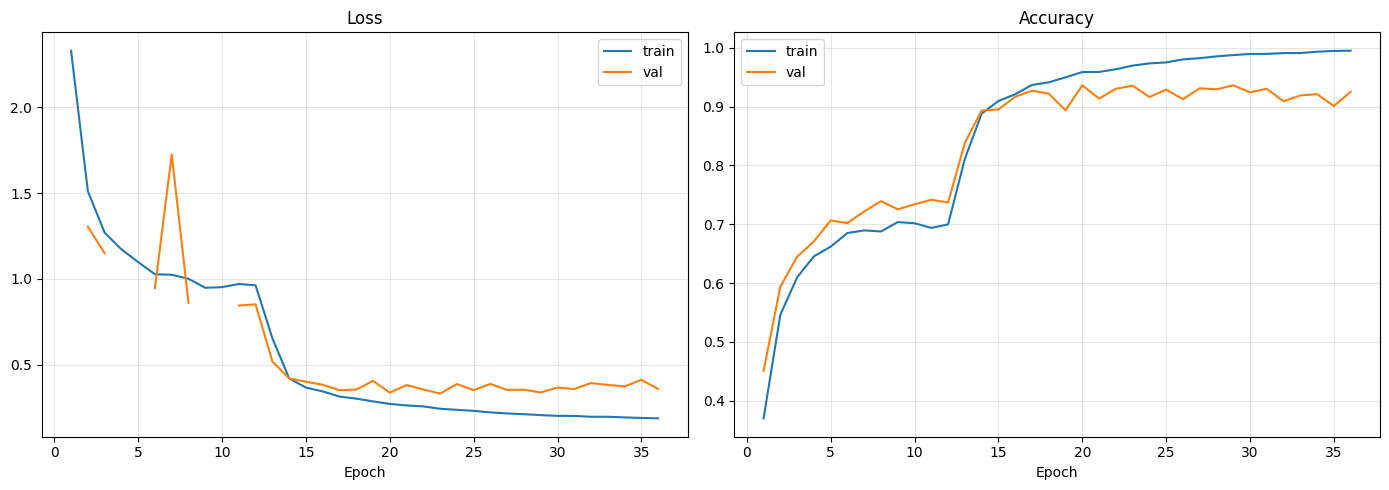

Best model val_acc: 93.61%


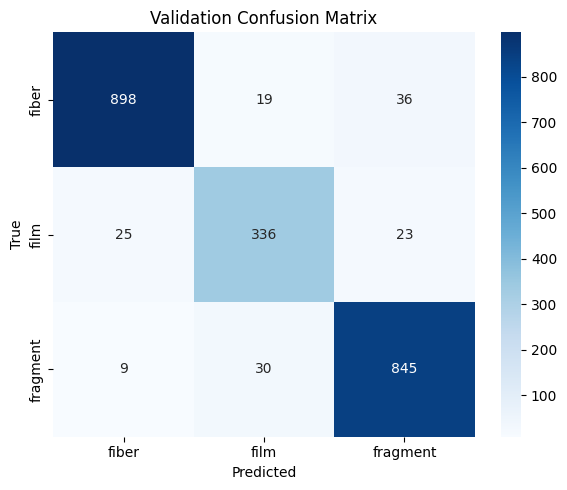

Classification report:
              precision    recall  f1-score   support

       fiber     0.9635    0.9423    0.9528       953
        film     0.8727    0.8750    0.8739       384
    fragment     0.9347    0.9559    0.9452       884

    accuracy                         0.9361      2221
   macro avg     0.9237    0.9244    0.9239      2221
weighted avg     0.9364    0.9361    0.9361      2221



In [8]:
# Plot curves
epochs = [x['epoch'] for x in all_history]
tr_loss = [x['train_loss'] for x in all_history]
va_loss = [x['val_loss'] for x in all_history]
tr_acc = [x['train_acc'] for x in all_history]
va_acc = [x['val_acc'] for x in all_history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, tr_loss, label='train')
axes[0].plot(epochs, va_loss, label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, tr_acc, label='train')
axes[1].plot(epochs, va_acc, label='val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_training_curves.png', dpi=150)
plt.show()

# Final validation report from best model
best_ckpt = torch.load(OUTPUT_ROOT / 'efficientnet_best.pth', map_location=device, weights_only=False)
model = get_model(freeze_backbone=False).to(device)
model.load_state_dict(best_ckpt['model_state_dict'])

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)
va_loss, va_acc, y_true, y_pred = run_epoch(model, val_loader, criterion, optimizer=None, scaler=None)
print(f'Best model val_acc: {va_acc:.2%}')

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Validation Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_confusion_matrix.png', dpi=150)
plt.show()

print('Classification report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

## 9. Save and Download

In [9]:
print('Saved artifacts:')
for p in sorted(OUTPUT_ROOT.glob('*.pth')):
    print(f'- {p} ({p.stat().st_size / 1e6:.1f} MB)')

print('')
print('Additional outputs:')
for p in [
    Path('/kaggle/working/efficientnet_training_curves.png'),
    Path('/kaggle/working/efficientnet_confusion_matrix.png')
]:
    if p.exists():
        print(f'- {p}')

print('')
print('How to download:')
print('1. Click Save Version')
print('2. Open Output tab')
print('3. Download /kaggle/working/experiments/efficientnet/mp_effnet_b3_cls3/efficientnet_best.pth')

Saved artifacts:
- /kaggle/working/experiments/efficientnet/mp_effnet_b3_cls3/efficientnet_best.pth (129.3 MB)
- /kaggle/working/experiments/efficientnet/mp_effnet_b3_cls3/efficientnet_latest.pth (129.3 MB)

Additional outputs:
- /kaggle/working/efficientnet_training_curves.png
- /kaggle/working/efficientnet_confusion_matrix.png

How to download:
1. Click Save Version
2. Open Output tab
3. Download /kaggle/working/experiments/efficientnet/mp_effnet_b3_cls3/efficientnet_best.pth
